# Basic LSTM Demonstration

Author: Pete King

This notebook demonstrates the ability of a LSTM model to analyze time series data and make predictions on a trivial dataset.  It serves several purposes for the author:

 1. Verify understanding of [LSTM parameters in PyTorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
 2. Verify understanding of tensor shape requirements for LSTM model input, hidden state, and output in PyTorch
 3. Explore the operation of PyTorch Datasets and DataLoaders with unbatched and batched input, particularly the resulting tensors produced for LSTM model input.  Confirm tensor shapes are aligned with LSTM model input requirements.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from helpers import data_prep as dp
from helpers import models

WINDOW_SIZE = 10  # Size of the rolling window used to create the sequence
BATCH_SIZE = 5

## I. Prepare Data

The ultimate goal with this notebook is to improve the author's understanding of how Datasets, DataLoaders, and the LSTM model behave in PyTorch.  Getting it right for this toy dataset will reinforce basic concepts before attempting a more complicated (possibly multivariate) deep learning model based on the LSTM architecture.

### Create Toy Dataset

Here we generate a sine wave to serve as a simplistic dataset for training the LSTM.  We expect that the LSTM will only be able to learn to predict the next value in the series if we have set up the input features, datasets, and dataloaders correctly.


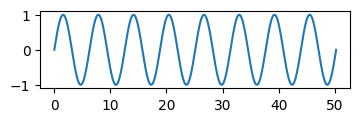

In [2]:
# Toy Data: A simple cosine wave
t = np.linspace(0, torch.pi * 16, 10**3).astype(np.float32)  # required for LSTM
x = np.sin(t).astype(np.float32)

# Plot data
fig = plt.figure(figsize=(4, 1))
ax = fig.subplots()
ax.plot(t, x)

### Generate input feature vectors and labels

We operate on the idea that the sine wave represents a simple repeating pattern that an LSTM can learn.  We use a backward-looking rolling window of length *L* to generate feature vectors.  Each feature vector is a sequence of values of the sine function at successive timestamps.  Thus each feature vector encodes a segment of sine wave.  This encoding is only useful if there are patterns in the sine wave that repeat over time (and thus can be used to predict a future value).

Consider each feature vector (x_(t-L)) as a sample of the data taken at time t, from time (t - L) to time (t - 1).

In this example, we try to predict the value (y) of the sine wave at time t (i.e., y = sin(t)).  Without batching samples, our input to the LSTM will be a matrix (X) where each row is a feature vector of length L, and there are (n - L) feature vectors (rows) total, where n is the total number of data points in the series.

In [3]:
# The dataset uses a backward-looking rolling window to generate feature 
# vectors from timestamps [t - window_size, t), i.e., the data at time t is 
# not included in the feature vector.

dataset = dp.UnivariateTimeSeriesDataset(x, window_size=WINDOW_SIZE)
x_0, y_0 = dataset[0][0], dataset[0][1]
print('First sample in the dataset:')
print(x_0)
print(f'Shape of first sample: {x_0.shape}')
print(f'First label in the dataset: {y_0}')
print(f'Shape of first label: {y_0.shape}')

First sample in the dataset:
tensor([[0.0000],
        [0.0503],
        [0.1005],
        [0.1504],
        [0.1999],
        [0.2489],
        [0.2973],
        [0.3450],
        [0.3917],
        [0.4375]])
Shape of first sample: torch.Size([10, 1])
First label in the dataset: tensor([0.4822])
Shape of first label: torch.Size([1])


**We verify that the label (y = sin(t)) is not included in the input feature vector (x).**

In [4]:
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
# Verify shape of input tensors
input_0, label_0 = next(iter(dataloader))
print(f'Shape of input tensor: {input_0.shape}')
print(f'Shape of label: {label_0.shape}')

Shape of input tensor: torch.Size([5, 10, 1])
Shape of label: torch.Size([5, 1])


## II. Create and Train LSTM Model

In [5]:
# Set an accelerator device (e.g., CUDA) if available.
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
else:
    device = 'cpu'

print(f'Device: {device}')

Device: cpu


In [6]:
# Define LSTM parameters
input_size = 1  # Number of features in data (x), in this case scalar values
hidden_size = 16  # Number of 'neurons' (features) in each hidden layer
num_layers = 1  # Number of LSTM layers in the model stack
batch_first = True  # Determines order of dimensions for input/output tensors
bidirectional = False  # If True, becomes a bidirectional LSTM
proj_size = 0  # If > 0, will use LSTM with projections of corresponding size

# Define variables for LSTM input/output tensor dimensions IAW PyTorch docs
N = BATCH_SIZE  # batch size
L = 1  # sequence length (number of successive feature vectors to consider)
D = int(bidirectional + 1)  # D = 1 (not birectional) or 2 (bidirectional)
H_in = input_size  # scalar input
H_cell = hidden_size
H_out = (proj_size if proj_size > 0 else H_in)

# Define number of dimensions in target labels (y) for multivariate LSTM
label_size = 1  # Number of features in labels, in this case scalar values

In [7]:
model = models.FinancialLSTM(
    input_size,
    label_size,
    hidden_size,
    num_layers,
    batch_first,
    bidirectional,
    proj_size,
)

In [8]:
# Define loss function and optimizer
# For multivariate loss, set parameter reduction='none'
loss_fn = torch.nn.L1Loss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters())

In [9]:
# Train and evaluate model
epochs = 10
all_preds = []
print(f'Training model over {epochs} epochs...')
for epoch in range(epochs):
    loss_trn = models.train_model(dataloader, model, loss_fn, optimizer)
    loss_val, preds = models.evaluate_model(dataloader, model, loss_fn)
    all_preds.append(preds)
    if epochs <= 20:
        print(f'Epoch {epoch + 1}')
        print(f'Training loss:   {loss_trn}')
        print(f'Validation loss: {loss_val}')
    else:
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch + 1}')
            print(f'Training loss:   {loss_trn}')
            print(f'Validation loss: {loss_val}')

Training model over 10 epochs...
Epoch 1
Training loss:   0.47668400406837463
Validation loss: 0.46771955490112305
Epoch 2
Training loss:   0.3121492266654968
Validation loss: 0.30514028668403625
Epoch 3
Training loss:   0.10309959948062897
Validation loss: 0.0941867008805275
Epoch 4
Training loss:   0.03626393526792526
Validation loss: 0.026405710726976395
Epoch 5
Training loss:   0.029317328706383705
Validation loss: 0.02626829966902733
Epoch 6
Training loss:   0.0048330994322896
Validation loss: 0.007167698349803686
Epoch 7
Training loss:   0.016945654526352882
Validation loss: 0.009592271409928799
Epoch 8
Training loss:   0.024011632427573204
Validation loss: 0.01833820343017578
Epoch 9
Training loss:   0.08276879787445068
Validation loss: 0.08328865468502045
Epoch 10
Training loss:   0.04194555804133415
Validation loss: 0.02952958084642887


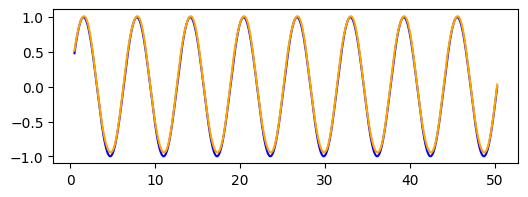

In [10]:
fig = plt.figure(figsize=(6, 2))
ax = fig.subplots()
ax.plot(t[WINDOW_SIZE:], x[WINDOW_SIZE:], color='blue')
ax.plot(t[WINDOW_SIZE:], preds, color='orange')

We see that the model can learn the pattern of a very simple stationary wave almost perfectly.  This suggests that we have a technically correct implementation of the LSTM model and are introducing data to it using correct tensor shapes.  The poor performance we saw in notebook 'Pete-A3' is then likely due to a problem with the input features.  We will create a new 'B-series' of notebooks to transform raw data into more useful features.  We will also experiment with other model types that might provide better performance than a LSTM-based deep learning model.